# 1D two-phase R134a cold-plate model, 32 parallel microchannels

Steady saturated flow boiling at Tsat = 10 degC. Thermophysical properties are
obtained from CoolProp. REFPROP can be selected if it is installed and licensed.

The model predicts local equilibrium quality, homogeneous void fraction, a
diagnostic flow-pattern label, Gungor-Winterton pre-dryout boiling HTC, AlN wall
temperature, and homogeneous-model pressure drop.

IMPORTANT: This is a screening model, not a safety-qualified design model.
Parallel-channel instability, maldistribution, conjugate 3D spreading, local hot
spots, flow reversal, dryout and CHF require experimental or validated CFD checks.

In [9]:
# In a fresh environment, uncomment one command:
%pip install CoolProp
# For NIST REFPROP, install REFPROP separately and configure its library path.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import CoolProp
    from CoolProp.CoolProp import PropsSI
except ImportError as exc:
    raise ImportError('CoolProp is required. Run: pip install CoolProp') from exc

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: C:\Users\Vahid\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 1. Geometry and operating conditions

In [10]:
# 32 identical rectangular fluid paths
N_channels = 32
w_ch = 0.4067e-3          # channel width [m]
h_ch = 5.5008e-3          # channel height [m]
L = 25.0e-3               # channel length [m]
A_ch = w_ch * h_ch
P_wet_ch = 2.0 * (w_ch + h_ch)
A_flow_total = N_channels * A_ch
P_wet_total = N_channels * P_wet_ch
D_h = 4.0 * A_ch / P_wet_ch

# AlN heater / substrate
heater_length = 30.0e-3   # [m], longer than fluid path, so full path is heated
heater_width = 48.0e-3    # [m]
t_AlN = 3.0e-3            # [m]
k_AlN = 170.0             # [W/m-K]

# Thermal and flow boundary conditions
Q_total = 2500.0            # [W]
m_dot_total = 0.050        # total refrigerant mass flow [kg/s]
T_sat_C = 10.0             # saturation temperature [degC]
x_in = 0.0                 # saturated-liquid inlet quality; edit if inlet differs
h_ambient = 10.0           # [W/m2-K]
T_ambient_C = 22.0         # [degC]

# Backend: 'HEOS' uses CoolProp; choose 'REFPROP' if NIST REFPROP is installed.
BACKEND = 'HEOS'
FLUID = f'{BACKEND}::R134a'

# Numerical grid
N = 301
x_ax = np.linspace(0.0, L, N)
dx = x_ax[1] - x_ax[0]

# Uniform applied heating over the full 25 mm fluid path.
q_prime_applied = Q_total / L                  # [W/m]
qpp_heater = Q_total / (heater_length * heater_width)  # package heat flux [W/m2]
qpp_wetted = Q_total / (P_wet_total * L)       # mean channel-wall heat flux [W/m2]

## 2. Saturated R134a properties from CoolProp or REFPROP

In [11]:
T_sat_K = T_sat_C + 273.15
P_sat = PropsSI('P', 'T', T_sat_K, 'Q', 0, FLUID)
P_crit = PropsSI('PCRIT', FLUID)
M = PropsSI('MOLARMASS', FLUID) * 1000.0       # [kg/kmol], Cooper correlation

rho_l = PropsSI('D', 'T', T_sat_K, 'Q', 0, FLUID)
rho_v = PropsSI('D', 'T', T_sat_K, 'Q', 1, FLUID)
mu_l = PropsSI('V', 'T', T_sat_K, 'Q', 0, FLUID)
mu_v = PropsSI('V', 'T', T_sat_K, 'Q', 1, FLUID)
k_l = PropsSI('L', 'T', T_sat_K, 'Q', 0, FLUID)
cp_l = PropsSI('C', 'T', T_sat_K, 'Q', 0, FLUID)
sigma = PropsSI('I', 'T', T_sat_K, 'Q', 0, FLUID)
h_l = PropsSI('H', 'T', T_sat_K, 'Q', 0, FLUID)
h_v = PropsSI('H', 'T', T_sat_K, 'Q', 1, FLUID)
h_fg = h_v - h_l
p_r = P_sat / P_crit

G = m_dot_total / A_flow_total                 # mass flux [kg/m2-s]
m_dot_ch = m_dot_total / N_channels
Bo = qpp_wetted / (G * h_fg)
Co = np.sqrt(sigma / (9.80665 * (rho_l - rho_v))) / D_h

print(f'CoolProp version: {CoolProp.__version__}; backend: {BACKEND}')
print(f'Psat = {P_sat/1e5:.4f} bar at {T_sat_C:.2f} degC')
print(f'Dh = {D_h*1e3:.4f} mm, total flow area = {A_flow_total*1e6:.3f} mm2')
print(f'G = {G:.1f} kg/m2-s; m_dot/channel = {m_dot_ch*1000:.4f} g/s')
print(f'hfg = {h_fg/1000:.2f} kJ/kg; qpp_wetted = {qpp_wetted/1000:.1f} kW/m2')
print(f'Bo = {Bo:.3e}; confinement number Co = {Co:.3f}')

CoolProp version: 7.1.0; backend: HEOS
Psat = 4.1461 bar at 10.00 degC
Dh = 0.7574 mm, total flow area = 71.590 mm2
G = 698.4 kg/m2-s; m_dot/channel = 1.5625 g/s
hfg = 190.74 kJ/kg; qpp_wetted = 264.5 kW/m2
Bo = 1.985e-03; confinement number Co = 1.199


## 3. Boiling HTC and pressure-drop functions

The Gungor-Winterton form combines convective boiling and a Cooper nucleate-
boiling term. It is used only before dryout. A hydraulic-diameter correction is
not silently introduced. The result should be uncertainty-banded for this highly
non-circular channel.

In [12]:
def churchill_fanning(Re):
    """Fanning friction factor, smooth passage, all Reynolds numbers."""
    Re = max(float(Re), 1e-12)
    A = (2.457 * np.log(1.0 / ((7.0/Re)**0.9 + 0.27*1e-12)))**16
    B = (37530.0/Re)**16
    return 2.0 * ((8.0/Re)**12 + 1.0/(A+B)**1.5)**(1.0/12.0)


def cooper_pool_boiling_htc(qpp, roughness_um=1.0):
    """Cooper pool-boiling HTC [W/m2-K]; qpp in W/m2.

    Surface roughness is unknown, so Rp=1 micrometre is an explicit assumption.
    """
    exponent = 0.12 - 0.2*np.log10(roughness_um)
    return 55.0 * p_r**exponent * (-np.log10(p_r))**(-0.55) * M**(-0.5) * qpp**0.67


def gungor_winterton_htc(quality, qpp):
    """Pre-dryout saturated flow-boiling HTC [W/m2-K]."""
    q = float(np.clip(quality, 1e-7, 0.999999))
    Re_l = G * (1.0-q) * D_h / mu_l
    Pr_l = cp_l * mu_l / k_l
    f_D_l = 4.0 * churchill_fanning(Re_l)
    Nu_l = ((f_D_l/8.0)*(Re_l-1000.0)*Pr_l /
            (1.0 + 12.7*np.sqrt(f_D_l/8.0)*(Pr_l**(2/3)-1.0))) if Re_l > 3000 else 4.36
    h_lo = max(Nu_l, 0.1) * k_l / D_h
    E = 1.0 + 3000.0*Bo**0.86 + 1.12*(q/(1.0-q))**0.75*(rho_l/rho_v)**0.41
    S = 1.0 / (1.0 + 1.15e-6 * E**2 * Re_l**1.17)
    h_nb = cooper_pool_boiling_htc(qpp)
    return E*h_lo + S*h_nb, E, S


def void_fraction_homogeneous(quality):
    q = np.clip(quality, 0.0, 1.0)
    if q <= 0.0:
        return 0.0
    return 1.0 / (1.0 + ((1.0-q)/q)*(rho_v/rho_l))


def diagnostic_flow_pattern(quality, alpha):
    """Screening label, not a substitute for a validated microchannel flow map."""
    if quality <= 1e-5:
        return 'saturated liquid / ONB entrance'
    if alpha < 0.25:
        return 'bubbly'
    if alpha < 0.60:
        return 'confined bubble / slug'
    if alpha < 0.85:
        return 'churn / transitional'
    return 'annular tendency'

## 4. Axial energy, wall temperature and pressure drop

Saturated inlet enthalpy plus cumulative heat determines equilibrium quality.
Ambient loss is small and estimated iteratively from the AlN top temperature.
Pressure loss uses a homogeneous equilibrium mixture model and includes friction
plus acceleration. Gravity and manifold losses are excluded.

In [13]:
q_to_fluid_prime = np.full(N, q_prime_applied)
T_wall = np.full(N, T_sat_C + 5.0)

for iteration in range(100):
    cumulative_heat = np.concatenate(([0.0], np.cumsum(0.5*(q_to_fluid_prime[1:] + q_to_fluid_prime[:-1])*dx)))
    quality = x_in + cumulative_heat/(m_dot_total*h_fg)
    quality_clip = np.clip(quality, 0.0, 0.999999)

    h_tp = np.empty(N)
    E_arr = np.empty(N)
    S_arr = np.empty(N)
    alpha = np.empty(N)
    pattern = []
    for i, q in enumerate(quality_clip):
        h_tp[i], E_arr[i], S_arr[i] = gungor_winterton_htc(q, max(q_to_fluid_prime[i]/P_wet_total, 1.0))
        alpha[i] = void_fraction_homogeneous(q)
        pattern.append(diagnostic_flow_pattern(q, alpha[i]))

    # Series resistance from saturated fluid to top of 3 mm AlN.
    # Heat spreads over the 48 mm plate width after crossing the channel wall.
    qpp_local_wet = q_to_fluid_prime/P_wet_total
    T_wall_fluid_side = T_sat_C + qpp_local_wet/h_tp
    T_wall_new = T_wall_fluid_side + (q_to_fluid_prime/heater_width)*t_AlN/k_AlN

    q_ambient_prime = h_ambient*heater_width*(T_wall_new - T_ambient_C)
    q_to_fluid_new = np.maximum(q_prime_applied - q_ambient_prime, 0.0)
    err = max(np.max(np.abs(T_wall_new-T_wall)), np.max(np.abs(q_to_fluid_new-q_to_fluid_prime)))
    T_wall = 0.6*T_wall_new + 0.4*T_wall
    q_to_fluid_prime = 0.6*q_to_fluid_new + 0.4*q_to_fluid_prime
    if err < 1e-7:
        break

# Homogeneous equilibrium pressure model
rho_mix = 1.0/(quality_clip/rho_v + (1.0-quality_clip)/rho_l)
mu_mix = 1.0/(quality_clip/mu_v + (1.0-quality_clip)/mu_l)
Re_mix = G*D_h/mu_mix
f_D_mix = np.array([4.0*churchill_fanning(r) for r in Re_mix])
dpdx_f = f_D_mix * G**2/(2.0*rho_mix*D_h)
dp_friction = np.trapz(dpdx_f, x_ax)
dp_acceleration = G**2*(1.0/rho_mix[-1] - 1.0/rho_mix[0])
dp_total = dp_friction + dp_acceleration

Q_fluid = m_dot_total*h_fg*(quality[-1]-x_in)
Q_ambient = np.trapz(q_prime_applied-q_to_fluid_prime, x_ax)

## 5. Dryout / boiling-crisis screening

In a microchannel evaporator the expected limiting event is normally annular-film
depletion and dryout, rather than classical pool-boiling DNB. This script does not
manufacture a CHF number from an unvalidated generic formula. Instead it reports
quality, annular tendency and heat flux, and allows a user-supplied validated
dryout-quality or CHF threshold to be applied when test data are available.

In [14]:
validated_x_dryout = None     # example: 0.65 only if supported by your validated source/data
validated_CHF_W_m2 = None     # enter a validated local CHF for this geometry and condition

if validated_x_dryout is None:
    dryout_quality_flag = 'not evaluated: no validated x_dryout supplied'
else:
    dryout_quality_flag = 'PASS' if quality.max() < validated_x_dryout else 'FAIL'

if validated_CHF_W_m2 is None:
    CHF_flag = 'not evaluated: no validated CHF supplied'
    CHF_margin = np.nan
else:
    CHF_margin = validated_CHF_W_m2/qpp_wetted
    CHF_flag = 'PASS' if CHF_margin > 1.0 else 'FAIL'

print('\nRESULTS')
print(f'Outlet equilibrium quality = {quality[-1]:.4f}')
print(f'Outlet homogeneous void fraction = {alpha[-1]:.4f}')
print(f'Flow-pattern sequence = {" -> ".join(dict.fromkeys(pattern))}')
print(f'Boiling HTC range = {h_tp.min()/1000:.2f} to {h_tp.max()/1000:.2f} kW/m2-K')
print(f'Maximum AlN top temperature = {T_wall.max():.2f} degC')
print(f'Q to R134a = {Q_fluid:.2f} W; Q to ambient = {Q_ambient:.2f} W')
print(f'Friction pressure drop = {dp_friction/1000:.3f} kPa')
print(f'Acceleration pressure drop = {dp_acceleration/1000:.3f} kPa')
print(f'Total channel pressure drop = {dp_total/1000:.3f} kPa, excluding manifolds')
print(f'Dryout-quality check: {dryout_quality_flag}')
print(f'CHF check: {CHF_flag}')
print('Model selection: pre-dryout nucleate + convective flow boiling; '
      'monitor annular-film dryout rather than treating classical DNB as the only limit.')


RESULTS
Outlet equilibrium quality = 0.2621
Outlet homogeneous void fraction = 0.9568
Flow-pattern sequence = saturated liquid / ONB entrance -> bubbly -> confined bubble / slug -> churn / transitional -> annular tendency
Boiling HTC range = 13.21 to 14.69 kW/m2-K
Maximum AlN top temperature = 66.77 degC
Q to R134a = 2499.47 W; Q to ambient = 0.53 W
Friction pressure drop = 1.829 kPa
Acceleration pressure drop = 6.219 kPa
Total channel pressure drop = 8.048 kPa, excluding manifolds
Dryout-quality check: not evaluated: no validated x_dryout supplied
CHF check: not evaluated: no validated CHF supplied
Model selection: pre-dryout nucleate + convective flow boiling; monitor annular-film dryout rather than treating classical DNB as the only limit.


In [15]:
results = pd.DataFrame({
    'x_m': x_ax,
    'equilibrium_quality': quality,
    'homogeneous_void_fraction': alpha,
    'flow_pattern_diagnostic': pattern,
    'boiling_htc_W_m2K': h_tp,
    'AlN_top_temperature_C': T_wall,
    'heat_to_R134a_W_per_m': q_to_fluid_prime,
    'mixture_density_kg_m3': rho_mix,
    'friction_gradient_Pa_m': dpdx_f,
})
results.to_csv('r134a_2phase_1d_results.csv', index=False)
results.head()

,x_m,equilibrium_quality,homogeneous_void_fraction,flow_pattern_diagnostic,boiling_htc_W_m2K,AlN_top_temperature_C,heat_to_R134a_W_per_m,mixture_density_kg_m3,friction_gradient_Pa_m
0,0.000000,0.000000,0.000000,saturated liquid / ONB entrance,13212.768689,66.770585,99978.510119,1260.957688,7736.633829
1,0.000083,0.000874,0.051693,bubbly,13216.786703,66.764503,99978.513039,1196.819987,8267.312580
2,0.000167,0.001747,0.098383,bubbly,13220.796302,66.758436,99978.515951,1138.891112,8867.022174
3,0.000250,0.002621,0.140761,bubbly,13224.811624,66.752365,99978.518865,1086.311122,9527.977955
4,0.000333,0.003494,0.179399,bubbly,13228.833680,66.746287,99978.521782,1038.371873,10240.064840


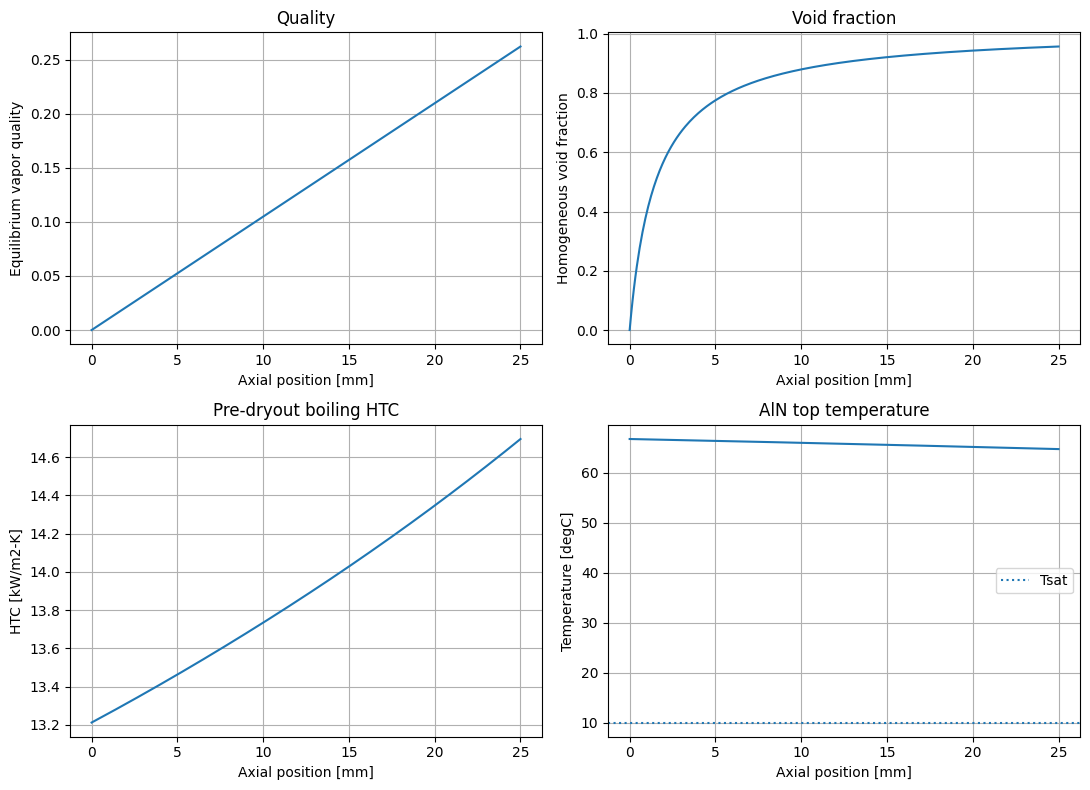

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0,0].plot(x_ax*1000, quality)
axes[0,0].set(xlabel='Axial position [mm]', ylabel='Equilibrium vapor quality', title='Quality')
axes[0,1].plot(x_ax*1000, alpha)
axes[0,1].set(xlabel='Axial position [mm]', ylabel='Homogeneous void fraction', title='Void fraction')
axes[1,0].plot(x_ax*1000, h_tp/1000)
axes[1,0].set(xlabel='Axial position [mm]', ylabel='HTC [kW/m2-K]', title='Pre-dryout boiling HTC')
axes[1,1].plot(x_ax*1000, T_wall)
axes[1,1].axhline(T_sat_C, linestyle=':', label='Tsat')
axes[1,1].set(xlabel='Axial position [mm]', ylabel='Temperature [degC]', title='AlN top temperature')
axes[1,1].legend()
for ax in axes.flat:
    ax.grid(True)
fig.tight_layout()
plt.show()

## Interpretation and limitations

- With a saturated-liquid inlet, x_out is primarily fixed by Q/(m_dot*hfg).
- The diagnostic pattern may progress rapidly to an annular tendency because the
  R134a vapor density is much lower than the liquid density. Use a published R134a
  rectangular-microchannel map or visualization data for final regime boundaries.
- Gungor-Winterton is a practical pre-dryout screening correlation. For final
  microchannel design, compare it against Kim-Mudawar or another correlation whose
  geometry, pressure, mass-flux, quality and heat-flux validity ranges cover this case.
- The homogeneous pressure model can under- or over-predict separated-flow pressure
  loss. Replace it with a validated mini/microchannel two-phase correlation.
- Parallel-channel flow instabilities and nonuniform flow sharing are not represented.
- If the inlet is subcooled, add a single-phase preheat and ONB section instead of
  setting x_in=0. If the inlet has vapor, set x_in to the measured inlet quality.